**AVALIAÇÃO N2 - Inteligência Artificial **

Classificadores

Nomes:
- Alyssa Heluany - 061210002
- Guilherme Pereira - 061210033
- Guilherme Suarez - 061210026
- Heloísa Rades - 061210035
- Henrique Aímola - 061210030

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a AVALIÇÃO N2 DO 1º BIMESTRE. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercícico id=40922

1. Carregar os dataset do exercício:

In [ ]:
# Tratamento dos dados
import numpy as np
import pandas as pd
from collections import Counter

# Carregamento de dados do OpenML
from sklearn.datasets import fetch_openml

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Métricas de avaliação
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, confusion_matrix, classification_report
# removed plot_roc_curve as it is deprecated
# Plot dos gráficos
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns

#Check scikit-learn version
import sklearn
print(sklearn.__version__) # make sure the version is 0.23 or higher

#If the version is lower than 0.23, update scikit-learn
!pip install -U scikit-learn

1.7.2


In [ ]:
# Vamos carregar dados publicos
dados = fetch_openml(data_id=40922)
df = pd.DataFrame(dados.data,columns=dados.feature_names)

2. Fazer a análise exploratória dos dados

(Espera-se no minimo que seja verificado os tipos de dados envolvidos e suas médias, desvios padrões e distribuição dos dados - função describe())

In [ ]:
df.head()

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-29.2960
1,0.6722,-11.2330,-0.2344,-0.1757,0.0208,0.1269
2,0.4399,-14.8170,0.0722,-0.9105,0.1063,-24.3670
3,0.3031,-0.8125,0.0888,0.1199,-0.4099,-29.3360
4,0.4814,-0.9312,0.0359,0.0527,0.4379,24.9220


In [ ]:
df.describe()

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,-0.735403,-3.425864,-1.585894,0.005690,0.285645,0.281254
std,9.419857,5.633842,4.631486,11.779596,11.209552,18.821379
min,-53.505000,-32.990000,-37.538000,-44.306000,-74.647000,-94.800000
25%,-0.381800,-10.335000,-0.376000,-0.920700,-0.644825,-13.451250
50%,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,0.355500,-0.241775,-0.085900,0.888800,0.733700,13.982000
max,56.033000,26.680000,16.403000,48.742000,84.980000,112.662000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   acceleration_x  88588 non-null  float64
 1   acceleration_y  88588 non-null  float64
 2   acceleration_z  88588 non-null  float64
 3   gyro_x          88588 non-null  float64
 4   gyro_y          88588 non-null  float64
 5   gyro_z          88588 non-null  float64
dtypes: float64(6)
memory usage: 4.1 MB


In [ ]:
# Compreender o que deve ser classificado
dados.target

,activity
0,0
1,0
2,0
3,0
4,0
...,...
88583,0
88584,0
88585,0
88586,0


array([[<Axes: title={'center': 'acceleration_x'}>,
        <Axes: title={'center': 'acceleration_y'}>],
       [<Axes: title={'center': 'acceleration_z'}>,
        <Axes: title={'center': 'gyro_x'}>],
       [<Axes: title={'center': 'gyro_y'}>,
        <Axes: title={'center': 'gyro_z'}>]], dtype=object)

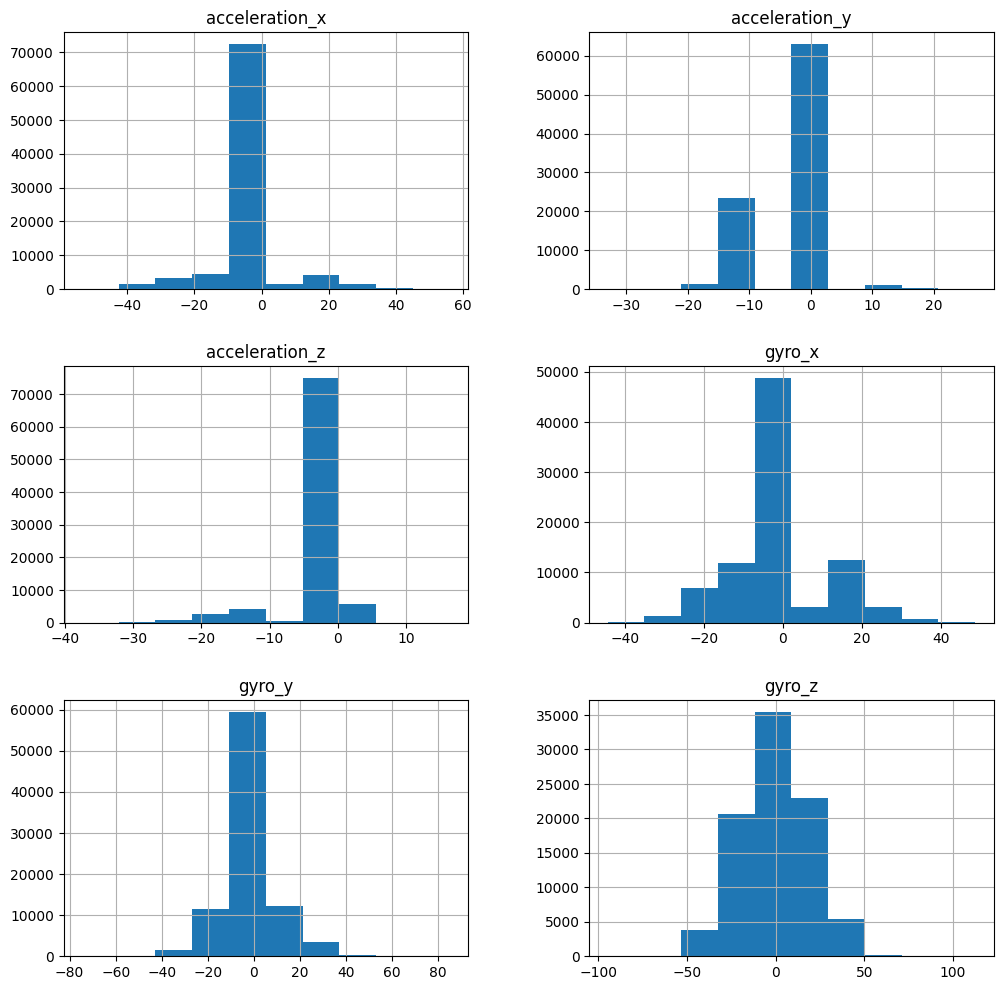

In [ ]:
df.hist(figsize=(12,12))

OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

Resposta:  
Os dados utilizados no dataset são provenientes dos eixos x,y e z de acelerômetro e giroscópio de celulares e o target é avaliar se a pessoa está correndo ou andando.  

De acordo com a explicação do dataset no site da OpenML, quando o target é 0, significa que está andando, e quando é 1, significa que está correndo.

3. Dividir os dados em conjunto de treinamento e treinar os modelos

In [ ]:
# Verificando a distribuição de classes
Counter(dados.target)

Counter({'0': 44223, '1': 44365})

In [ ]:
# Dividindo os dados no conjunto de teste e treinamento
X_train, X_test, y_train, y_test = train_test_split(dados.data, dados.target, test_size=0.3, random_state=42)

# Aplicando a padronizacao
# levantando os minimos e maximos
scaler = MinMaxScaler().fit(X_train)
# Mudando a escala dos dados
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

# Fazendo a regressao logistica
log_reg = LogisticRegression()
log_reg.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_log = log_reg.predict(x_test_scaled)

In [ ]:
!pip install --upgrade scikit-learn

Prompt para célula abaixo:
Com base no conjunto de dados e nas divisões de teste e treinamento que foram feitos na célula anterior, treine o modelo a partir de uma árvore de decisão para classificação

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Fazendo a arvore de decisão
tree_clf = DecisionTreeClassifier(random_state=31)
tree_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_tree = tree_clf.predict(x_test_scaled)

Prompt: Treine o modelo a partir do knn com base nos dados e divisões feitos no notebook

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Fazendo o KNN
knn_clf = KNeighborsClassifier()
knn_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_knn = knn_clf.predict(x_test_scaled)

prompt: Treine o modelo utilizando o svm para classificação com base nos dados e conjuntos que foram criados no notebook

In [ ]:
from sklearn.svm import SVC

# Fazendo o SVM
svm_clf = SVC(random_state=31)
svm_clf.fit(x_train_scaled, y_train)

# Fazendo as predições
y_pred_svm = svm_clf.predict(x_test_scaled)

In [ ]:
# Comparando usando o DataFrame
pd.DataFrame({'pred_log': y_pred_log, "pred_tree": y_pred_tree, "pred_knn": y_pred_knn,"pred_svm": y_pred_svm,'resp': y_test})

,pred_log,pred_tree,pred_knn,pred_svm,resp
57800,0,1,1,1,1
53690,1,1,1,1,1
75294,1,1,1,1,1
16113,1,1,1,1,1
88456,0,0,0,0,0
...,...,...,...,...,...
63775,0,1,0,0,1
10554,1,1,1,1,1
41523,1,0,0,0,0
54561,1,1,1,1,1


Prompt: Faça uma validação cruzada para cada modelo com o intuito de verificar se não houve overfit

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation for each model
log_reg_cv_scores = cross_val_score(log_reg, x_train_scaled, y_train, cv=5)
tree_clf_cv_scores = cross_val_score(tree_clf, x_train_scaled, y_train, cv=5)
knn_clf_cv_scores = cross_val_score(knn_clf, x_train_scaled, y_train, cv=5)
svm_clf_cv_scores = cross_val_score(svm_clf, x_train_scaled, y_train, cv=5)

# Print the cross-validation scores
print("Logistic Regression Cross-Validation Scores:", log_reg_cv_scores)
print("Decision Tree Cross-Validation Scores:", tree_clf_cv_scores)
print("KNN Cross-Validation Scores:", knn_clf_cv_scores)
print("SVM Cross-Validation Scores:", svm_clf_cv_scores)

Logistic Regression Cross-Validation Scores: [0.72103523 0.71907757 0.72206096 0.7146428  0.71827125]
Decision Tree Cross-Validation Scores: [0.98040797 0.98137397 0.98177713 0.98048702 0.9814546 ]
KNN Cross-Validation Scores: [0.96976538 0.96927915 0.96863409 0.96694082 0.97145622]
SVM Cross-Validation Scores: [0.95122148 0.94581519 0.94646025 0.94347686 0.94742783]


4. Metricas de desempenho

[Precisão, Revocação, Acurácia e F1-Score]

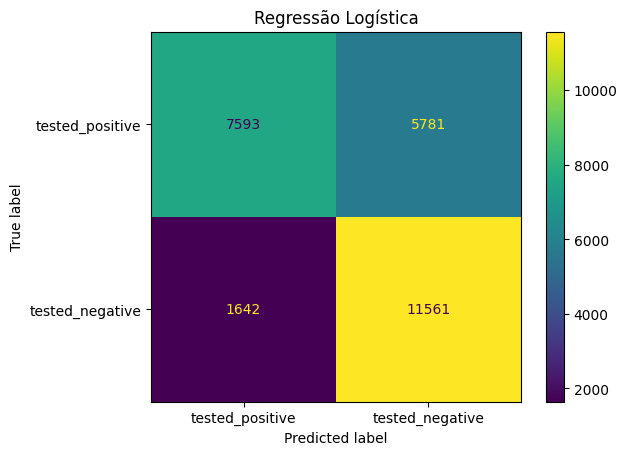

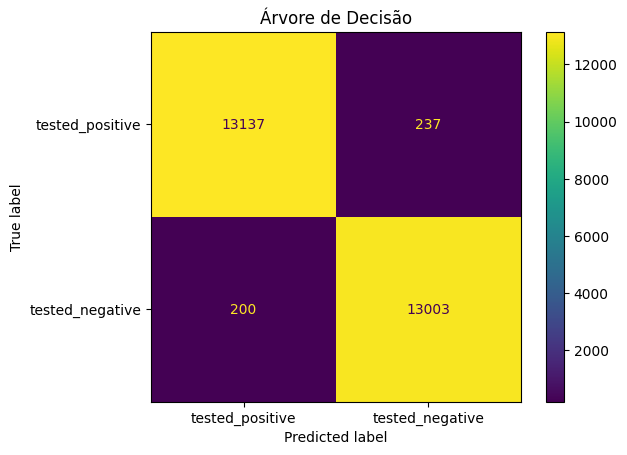

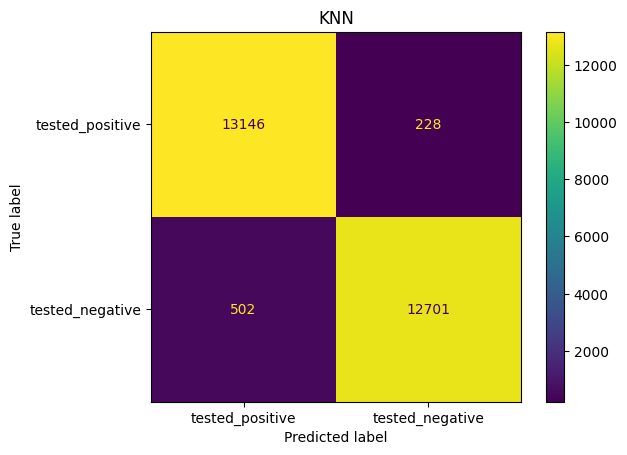

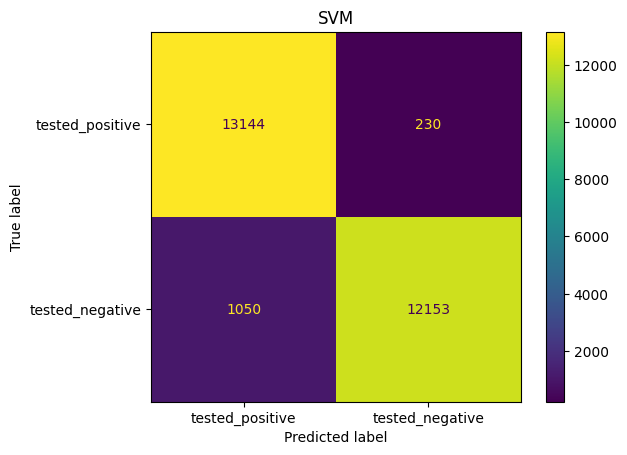

In [ ]:
resultados = [y_pred_log, y_pred_tree, y_pred_knn, y_pred_svm]
nomes = ["Regressão Logística", "Árvore de Decisão", "KNN", "SVM"]
matrizes_confusao = []


for i, pred in enumerate(resultados):
  cm = confusion_matrix(y_test, pred)
  matrizes_confusao.append(cm)
  dips = ConfusionMatrixDisplay(cm, display_labels=["tested_positive", "tested_negative"])
  dips.plot()
  plt.title(nomes[i])
  plt.show()

Os blocos abaixo foram autogerados pelo gemini quando foi solicitada a validação cruzada anteriormente.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, pos_label='1')
recall_log = recall_score(y_test, y_pred_log, pos_label='1')
f1_log = f1_score(y_test, y_pred_log, pos_label='1')

print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1-Score: {f1_log:.4f}")
print("-" * 30)

Logistic Regression Metrics:
Accuracy: 0.7207
Precision: 0.6666
Recall: 0.8756
F1-Score: 0.7570
------------------------------


In [ ]:
# Calculate metrics for Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, pos_label='1')
recall_tree = recall_score(y_test, y_pred_tree, pos_label='1')
f1_tree = f1_score(y_test, y_pred_tree, pos_label='1')

print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall: {recall_tree:.4f}")
print(f"F1-Score: {f1_tree:.4f}")
print("-" * 30)

Decision Tree Metrics:
Accuracy: 0.9836
Precision: 0.9821
Recall: 0.9849
F1-Score: 0.9835
------------------------------


In [ ]:
# Calculate metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label='1')
recall_knn = recall_score(y_test, y_pred_knn, pos_label='1')
f1_knn = f1_score(y_test, y_pred_knn, pos_label='1')

print("KNN Metrics:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print("-" * 30)

# Calculate metrics for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label='1')
recall_svm = recall_score(y_test, y_pred_svm, pos_label='1')
f1_svm = f1_score(y_test, y_pred_svm, pos_label='1')

print("SVM Metrics:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print("-" * 30)

KNN Metrics:
Accuracy: 0.9725
Precision: 0.9824
Recall: 0.9620
F1-Score: 0.9721
------------------------------
SVM Metrics:
Accuracy: 0.9518
Precision: 0.9814
Recall: 0.9205
F1-Score: 0.9500
------------------------------


Prompt: Plote a curva ROC de cada um dos modelos

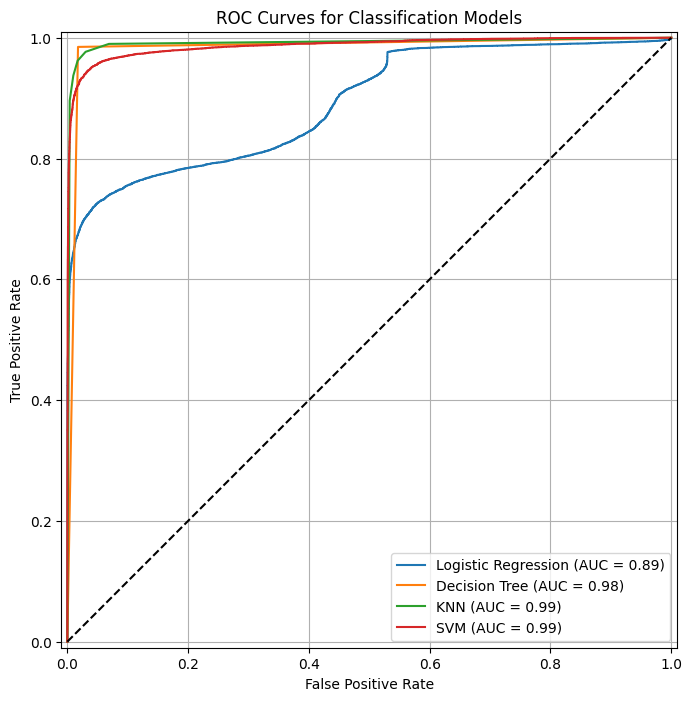

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve for each model
fig, ax = plt.subplots(figsize=(10, 8))

RocCurveDisplay.from_estimator(log_reg, x_test_scaled, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(tree_clf, x_test_scaled, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(knn_clf, x_test_scaled, y_test, ax=ax, name="KNN")
RocCurveDisplay.from_estimator(svm_clf, x_test_scaled, y_test, ax=ax, name="SVM")

plt.title('ROC Curves for Classification Models')
plt.plot([0, 1], [0, 1], 'k--')  # Plot the diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

5. Conclusão

Os resultados estão bons?

Analisando os resultados dos modelos treinados a partir das métricas, vemos que:
- A **Regressão Logística** teve os menores valores para acurácia, precisão e F1-score. Entretanto, o valor da revocação foi relativamente alto, indicando que o modelo é bom em identificar os casos positivos, mas tem uma precisão menor, pois também caracteriza erroneamente alguns dados negativos como positivos;
- A **Árvore de Decisão** mostrou altos valores nas métricas de avaliação, sugerindo que sua performance de distinção entre estar andando ou correndo pode ter bom desempenho, mas também um potencial para overfitting se o desempenho no conjunto de teste for significativamente menor;
- O **KNN** também tem um bom desempenho, pois seus valores de acurácia, precisão, revocação e F1-score são altos. Ele apresenta uma precisão um pouco maior que a árvore de decisão, mas uma revocação um pouco menor;
- O **SVM** também mostra bom desempenho, porém, menor que os modelos de KNN e árvore de decisão.

Logo, considerando as pontuações da validação cruzada e estas métricas do conjunto de teste, os modelos de Árvore de Decisão e KNN apresentam o melhor equilíbrio entre desempenho e generalização neste conjunto de dados. As altas pontuações da validação cruzada para a Árvore de Decisão e o KNN se refletem em suas altas pontuações no conjunto de teste, sugerindo que o overfitting não é um problema significativo para estes modelos.  

Em relação à validação cruzada, percebe-se que:
- para a **Regressão Logística**, a acurácia no conjunto de teste está muito próxima das pontuações da validação cruzada, ambos na casa de 0,72. Isso sugere que o modelo de Regressão Logística não está sofrendo de overfitting e está generalizando bem para novos dados, embora seu desempenho geral seja modesto;
- para a **Árvore de Decisão**, a acurácia no conjunto de teste é muito semelhante às pontuações da validação cruzada (próximos a 0,98). Isso indica que o modelo de Árvore de Decisão está generalizando bem para o conjunto de teste e não apresenta overfitting significativo, apesar de seu alto desempenho nas partições de treinamento;
- para o **KNN**, a acurácia no conjunto de teste está dentro do intervalo das pontuações da validação cruzada e muito próxima do limite superior desse intervalo (entre 0,96 e 0,97). Isso sugere que o modelo KNN também está generalizando bem e não apresenta overfitting;
- para o **SVM**, a acurácia no conjunto de teste é consistente com as pontuações da validação cruzada. Isso indica que o modelo SVM não apresenta sobreajuste (overfitting) e seu desempenho em dados não vistos é semelhante ao que teve nas partições de treinamento.  

Finalmente, analisando as curvas ROC e as métricas de performance, conclui-se:
- **Interpretação da Curva ROC**: A curva ROC representa graficamente a Taxa de Verdadeiros Positivos (True Positive Rate ou Recall) em função da Taxa de Falsos Positivos (False Positive Rate) para vários limiares de classificação. Um modelo com uma maior Área Sob a Curva (Area Under the Curve - AUC) é geralmente considerado melhor, pois indica uma maior probabilidade de distinguir entre as classes positiva e negativa. A curva que está mais próxima do canto superior esquerdo representa um modelo com melhor desempenho.

- **Análise dos Gráficos e das Métricas**:
    - As curvas ROC para os modelos de Árvore de Decisão e KNN estão muito próximas do canto superior esquerdo e possuem os maiores valores de AUC (embora não calculado explicitamente, isso é visualmente evidente). Isso condiz com suas altas pontuações de acurácia, precisão, recall e F1-score. Esses modelos apresentam um desempenho muito bom na classificação das atividades.

    - A curva ROC do modelo SVM está ligeiramente abaixo das curvas da Árvore de Decisão e do KNN, o que é consistente com sua acurácia, recall e F1-score um pouco mais baixos, embora sua precisão ainda seja alta.

    - A curva ROC do modelo de Regressão Logística está significativamente abaixo das outras, mais próxima da linha diagonal. Isso confirma seu desempenho inferior em todas as métricas em comparação com os outros modelos.

Em suma, as curvas ROC reforçam visualmente as conclusões tiradas a partir das métricas de desempenho individuais. Os modelos de Árvore de Decisão e KNN são os de melhor desempenho neste conjunto de dados, mostrando excelente capacidade de diferenciar entre caminhar e correr. O SVM também é bom, enquanto a Regressão Logística é menos eficaz para esta tarefa de classificação.